In [9]:
from vnstock_forecast.client.vietstock import OHLCV
from vnstock_forecast.utils import time_utils

In [27]:
from_ts = time_utils.time_to_timestamp("01-01-2026")
to_ts = time_utils.get_current_date_timestamp()
ohlcv = OHLCV()
df = ohlcv.fetch(from_ts, to_ts, "VHM", resolution="D")

<class 'requests.models.Response'>
<Response [200]>


In [28]:
df_plot = df.copy()
df_plot.index = df_plot["timestamp"].apply(lambda x: pd.to_datetime(time_utils.timestamp_to_str(x)))
df_plot = df_plot[["open", "high", "low", "close"]]
df_plot.columns = ["Open", "High", "Low", "Close"]
df_plot.index.name = "Date"
df_plot.index = pd.to_datetime(df_plot.index)

/tmp/ipykernel_249748/1511053367.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


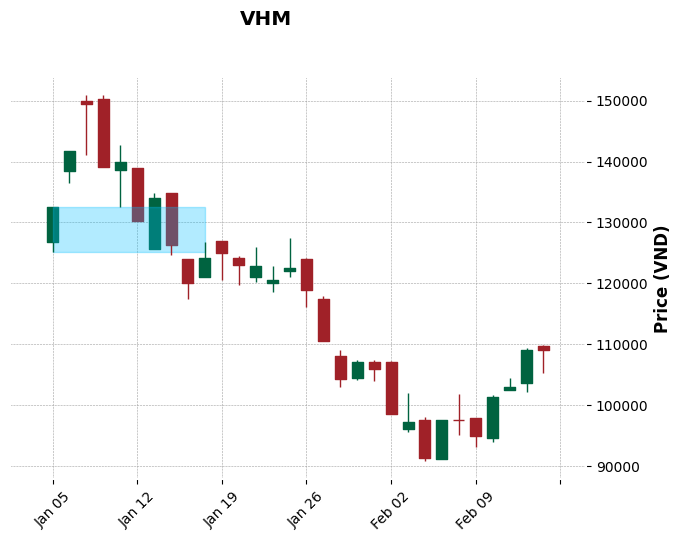

In [32]:
import mplfinance as mpf
from matplotlib.patches import Rectangle

fig, axes = mpf.plot(df_plot, type="candle", style="charles", title="VHM", ylabel="Price (VND)", returnfig=True)
ax = axes[0]

# Lấy đỉnh (high) và đáy (low) của nến đầu tiên
first_high = df_plot["High"].iloc[0]
first_low = df_plot["Low"].iloc[0]

# Vẽ hình chữ nhật từ nến 1 đến nến 10
rect = Rectangle(
    (0, first_low),           # Góc dưới trái (x=0 là nến đầu tiên)
    9,                        # Chiều rộng (từ nến 1 đến nến 10)
    first_high - first_low,   # Chiều cao (từ low đến high)
    facecolor='deepskyblue',
    alpha=0.3,
    edgecolor='deepskyblue',
    linewidth=1
)
ax.add_patch(rect)

fig.show()